# 事件类型聚合统计分析

本 notebook 用于统计 `event_type` 字段的所有唯一值及其出现次数，并找出拼写错误的异常数据。

In [1]:
import pandas as pd
import numpy as np
from collections import Counter

In [2]:
# 读取数据
df = pd.read_csv('large_data.csv')
print(f"数据总行数：{len(df)}")
print(f"数据列名：{df.columns.tolist()}")
df.head()

数据总行数：1000000
数据列名：['event_id', 'user_id', 'action_time', 'event_type', 'device_info', 'metadata']


,event_id,user_id,action_time,event_type,device_info,metadata
0,evt_e16af323-be7f-414a-a1df-7a59d248aa8e,719570,2023-06-28T21:29:57Z,view,"{""os"": ""Windows"", ""browser"": ""Chrome"", ""versio...",后端服务日志 [seq:28894]
1,evt_63909c65-9a4c-412e-9c86-78f56c3282d6,user_56392,2024-11-27T10:07:01Z,logout,"{""os"": ""macOS"", ""browser"": ""Safari"", ""version""...",正常用户行为记录 [seq:95648]
2,evt_3ee425d9-0367-4fd2-9a3b-d5407fba2cb4,user_83397,2025-01-10T21:01:14Z,logout,"{""os"": ""Windows"", ""browser"": ""Chrome"", ""versio...",后端服务日志 [seq:36435]
3,evt_e140c861-c24a-41ff-be6a-db035edddfed,745911,2023-05-27T22:10:40Z,search,"{""os"": ""macOS"", ""browser"": ""Firefox"", ""version...",正常用户行为记录 [seq:30022]
4,evt_92d28d61-3939-4992-93e9-9148201d1429,604731,2024-10-06T07:44:29Z,search,"{""os"": ""Android"", ""browser"": ""Edge"", ""version""...",API 调用日志 [seq:97913]


In [3]:
# 统计 event_type 的所有唯一值及其出现次数
event_type_counts = df['event_type'].value_counts()
print("\n=== event_type 唯一值及出现次数 ===")
print(event_type_counts)


=== event_type 唯一值及出现次数 ===
event_type
search      164499
login       164446
logout      164370
click       164046
purchase    163849
view        163749
purchse        880
serch          861
seach          848
vew            848
logut          843
purhcase       840
vieew          835
puchase        826
log-out        821
logot          821
viwe           802
serach         784
clik           673
clic           640
login          639
cllick         629
LogIn          623
logn           618
loign          617
ckick          593
Name: count, dtype: int64


In [4]:
# 计算各 event_type 的占比
total_count = len(df)
event_type_percentage = (event_type_counts / total_count * 100).round(4)

# 合并显示次数和占比
event_type_stats = pd.DataFrame({
    'count': event_type_counts.values,
    'percentage(%)': event_type_percentage.values
}, index=event_type_counts.index)

print("\n=== event_type 统计（含占比）===")
print(event_type_stats)


=== event_type 统计（含占比）===
             count  percentage(%)
event_type                       
search      164499        16.4499
login       164446        16.4446
logout      164370        16.4370
click       164046        16.4046
purchase    163849        16.3849
view        163749        16.3749
purchse        880         0.0880
serch          861         0.0861
seach          848         0.0848
vew            848         0.0848
logut          843         0.0843
purhcase       840         0.0840
vieew          835         0.0835
puchase        826         0.0826
log-out        821         0.0821
logot          821         0.0821
viwe           802         0.0802
serach         784         0.0784
clik           673         0.0673
clic           640         0.0640
login          639         0.0639
cllick         629         0.0629
LogIn          623         0.0623
logn           618         0.0618
loign          617         0.0617
ckick          593         0.0593


In [5]:
# 识别可能的拼写错误（异常数据）
# 正常的 event_type 应该是：view, click, search, login, logout, purchase 等
normal_types = ['view', 'click', 'search', 'login', 'logout', 'purchase']

all_types = event_type_counts.index.tolist()
abnormal_types = [t for t in all_types if t not in normal_types]

print("\n=== 可能的拼写错误/异常 event_type ===")
for abnormal in abnormal_types:
    count = event_type_counts[abnormal]
    percentage = count / total_count * 100
    print(f"  - '{abnormal}': {count} 条，占比 {percentage:.4f}%")


=== 可能的拼写错误/异常 event_type ===
  - 'purchse': 880 条，占比 0.0880%
  - 'serch': 861 条，占比 0.0861%
  - 'seach': 848 条，占比 0.0848%
  - 'vew': 848 条，占比 0.0848%
  - 'logut': 843 条，占比 0.0843%
  - 'purhcase': 840 条，占比 0.0840%
  - 'vieew': 835 条，占比 0.0835%
  - 'puchase': 826 条，占比 0.0826%
  - 'log-out': 821 条，占比 0.0821%
  - 'logot': 821 条，占比 0.0821%
  - 'viwe': 802 条，占比 0.0802%
  - 'serach': 784 条，占比 0.0784%
  - 'clik': 673 条，占比 0.0673%
  - 'clic': 640 条，占比 0.0640%
  - 'login ': 639 条，占比 0.0639%
  - 'cllick': 629 条，占比 0.0629%
  - 'LogIn': 623 条，占比 0.0623%
  - 'logn': 618 条，占比 0.0618%
  - 'loign': 617 条，占比 0.0617%
  - 'ckick': 593 条，占比 0.0593%


In [6]:
# 计算异常数据的总量和占比
abnormal_count = sum(event_type_counts[t] for t in abnormal_types)
abnormal_percentage = abnormal_count / total_count * 100

print("\n=== 异常数据汇总 ===")
print(f"异常 event_type 种类数：{len(abnormal_types)}")
print(f"异常数据总条数：{abnormal_count}")
print(f"异常数据占比：{abnormal_percentage:.4f}%")


=== 异常数据汇总 ===
异常 event_type 种类数：20
异常数据总条数：15041
异常数据占比：1.5041%


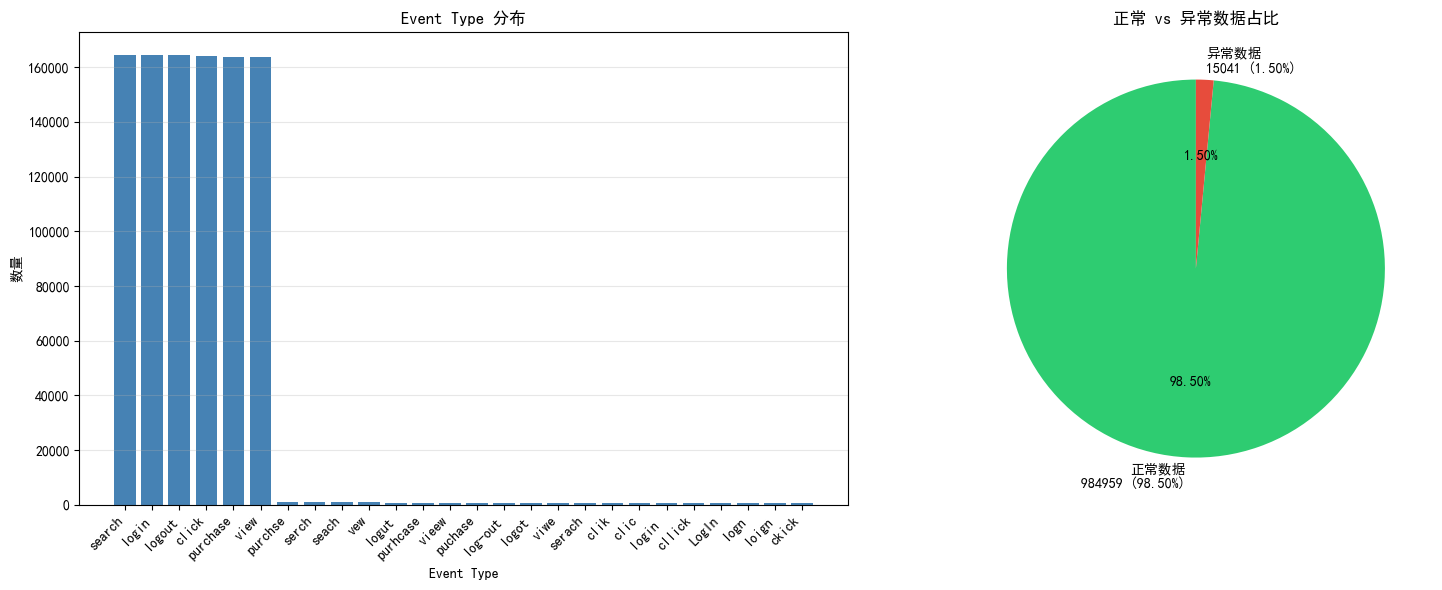


图表已保存为 event_type_analysis.png


In [7]:
# 可视化展示
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图 1：所有 event_type 的分布
axes[0].bar(range(len(event_type_counts)), event_type_counts.values, color='steelblue')
axes[0].set_xticks(range(len(event_type_counts)))
axes[0].set_xticklabels(event_type_counts.index, rotation=45, ha='right')
axes[0].set_title('Event Type 分布')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('数量')
axes[0].grid(axis='y', alpha=0.3)

# 图 2：正常 vs 异常数据占比
normal_count = total_count - abnormal_count
pie_data = [normal_count, abnormal_count]
pie_labels = [f'正常数据\n{normal_count} ({100-abnormal_percentage:.2f}%)', 
              f'异常数据\n{abnormal_count} ({abnormal_percentage:.2f}%)']
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(pie_data, labels=pie_labels, colors=colors, autopct='%1.2f%%', startangle=90)
axes[1].set_title('正常 vs 异常数据占比')

plt.tight_layout()
plt.savefig('event_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 event_type_analysis.png")